# Run Pi 0.5 on LIBERO

**On first session, run:** Sections 1 → 2 → 3 (full install, ~15 min) for setup, 4 for verification, 5 for benchmarking

**Every subsequent session:** Sections 1 → 2 -> 3b (restore from cache, shorter than Section 3) → 4 → 5 → 6

**Note:** Drive caching may not work depending on how much drive storage is available (~12GB)

On an **A100**, each forward pass seeems to take 20-60 seconds (time is highly variable)

---
## Section 1: GPU check + Drive mount

Run every session.

In [1]:
import subprocess, torch
print(subprocess.run(['nvidia-smi','--query-gpu=name,memory.total','--format=csv,noheader'],
                     capture_output=True, text=True).stdout.strip())
print(f'CUDA: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

NVIDIA A100-SXM4-80GB, 81920 MiB
CUDA: True
GPU: NVIDIA A100-SXM4-80GB
VRAM: 85.1 GB


In [ ]:
from google.colab import drive
import os
drive.mount('/content/drive')

DRIVE      = '/content/drive/MyDrive'

# NOTE: I know this is called smolvla_colab_cache, just ignore it for now, it was from the smolvla notebook
# and the packages carry over

CACHE_DIR  = f'{DRIVE}/smolvla_colab_cache'   # pip + package snapshot lives here
HF_HOME    = f'{DRIVE}/smolvla_colab_cache/hf_models'  # HuggingFace models
RESULTS_DIR= f'{DRIVE}/smolvla_results'

os.makedirs(CACHE_DIR, exist_ok=True)
os.makedirs(HF_HOME, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

# Point HF at Drive so model downloads persist across sessions
os.environ['HF_HOME'] = HF_HOME
os.environ['TOKENIZERS_PARALLELISM'] = 'false'
os.environ['MUJOCO_GL'] = 'egl'

SNAPSHOT = f'{CACHE_DIR}/site_packages.tar.gz'
snapshot_exists = os.path.exists(SNAPSHOT)
print(f'Cache dir:  {CACHE_DIR}')
print(f'HF models:  {HF_HOME}')
print(f'Snapshot:   {"FOUND — use Section 3b (fast restore)" if snapshot_exists else "not found — run Section 3 (full install) first"}')

Mounted at /content/drive


---
## Section 2: System libraries

Run **once per session** (only ~2 min — apt-get is fast and can't be cached to Drive easily).

In [ ]:
%%bash
apt-get update -qq
apt-get install -y -qq libosmesa6-dev libgl1-mesa-glx libglfw3 libglew-dev libegl1-mesa-dev patchelf ffmpeg
# EGL fix for Colab
mkdir -p /usr/share/glvnd/egl_vendor.d
echo '{"file_format_version":"1.0.0","ICD":{"library_path":"libEGL_nvidia.so.0"}}' \
    > /usr/share/glvnd/egl_vendor.d/10_nvidia.json
echo 'System deps done'

---
## Section 3: Full install (FIRST SESSION ONLY)

Run this only on your very first session, or if the snapshot becomes stale.
At the end it saves a snapshot to Drive. **Skip to Section 3b on subsequent sessions.**

In [ ]:
%%bash
pip install \
    mujoco \
    robosuite \
    libero \
    sentencepiece \
    tiktoken \
    "lerobot[pi0] @ git+https://github.com/huggingface/lerobot.git"
echo "Done"


  Cloning https://github.com/huggingface/lerobot.git to /tmp/pip-install-lisi0zlw/lerobot_f522753642bf473f9af53242c8041048
  Resolved https://github.com/huggingface/lerobot.git to commit 01dcb4c29222bc9f2388cebf87f0e79965a9508b
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.5/42.5 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 59.7 MB/s eta 0:00:00
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata

  Running command git clone --filter=blob:none --quiet https://github.com/huggingface/lerobot.git /tmp/pip-install-lisi0zlw/lerobot_f522753642bf473f9af53242c8041048


In [ ]:
# Verify that packages have installed properly (easy for conflicts to occur)

import torch
from lerobot.policies.pi05.modeling_pi05 import PI05Policy
print("PI05 import: OK")

from libero.libero import benchmark
print("LIBERO import: OK")

import mujoco
print(f"MuJoCo: {mujoco.__version__}")

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device}")


SmolVLA import: OK
Do you want to specify a custom path for the dataset folder? (Y/N): N
Initializing the default config file...
The following information is stored in the config file: /root/.libero/config.yaml
benchmark_root: /usr/local/lib/python3.12/dist-packages/libero/libero
bddl_files: /usr/local/lib/python3.12/dist-packages/libero/libero/./bddl_files
init_states: /usr/local/lib/python3.12/dist-packages/libero/libero/./init_files
datasets: /usr/local/lib/python3.12/dist-packages/libero/libero/../datasets
assets: /usr/local/lib/python3.12/dist-packages/libero/libero/./assets
LIBERO import: OK
MuJoCo: 3.8.1
Device: cuda


In [ ]:
# Login to HuggingFace (needed for gated PaliGemma tokenizer used by pi0.5)
from huggingface_hub import login, snapshot_download
import os

# Paste your HuggingFace token when prompted
# Get one at: https://huggingface.co/settings/tokens
# Also accept PaliGemma license at: https://huggingface.co/google/paligemma-3b-pt-224
login()

print(f'Downloading pi0.5 LIBERO checkpoint to {os.environ["HF_HOME"]} ...')
path = snapshot_download(repo_id='lerobot/pi05_libero_finetuned')
print(f'Checkpoint cached at: {path}')

# Pre-download PaliGemma tokenizer
print('Downloading PaliGemma tokenizer...')
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained('google/paligemma-3b-pt-224')
print('PaliGemma tokenizer cached.')


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 8 files:   0%|          | 0/8 [00:00<?, ?it/s]

Model cached at: /content/drive/MyDrive/smolvla_colab_cache/hf_models/hub/models--HuggingFaceVLA--smolvla_libero/snapshots/6721902bc4d61e50a3bfdb11dfb4cb626f05d102


In [ ]:
# Save snapshot of installed packages to Drive
# This is the step that makes future sessions fast (~2-3 min restore vs 15-20 min reinstall)
import subprocess, os, sys, shutil

print('Saving package snapshot locally first, then moving to Drive...')
LOCAL_SNAPSHOT = '/content/site_packages.tar.gz'
DRIVE_SNAPSHOT = f'{CACHE_DIR}/site_packages.tar.gz'

# Save site-packages automatically detecting python version
site_packages_dir = f'usr/local/lib/python3.{sys.version_info.minor}/dist-packages'

# 1. Tar to local disk (very fast)
result = subprocess.run([
    'tar', '-czf', LOCAL_SNAPSHOT,
    '-C', '/',
    site_packages_dir,
    'usr/local/bin',       # includes lerobot-train, lerobot-eval etc.
], capture_output=True, text=True)

if result.returncode == 0:
    # 2. Copy to Drive
    print('Copying to Google Drive...')
    shutil.copy(LOCAL_SNAPSHOT, DRIVE_SNAPSHOT)
    os.remove(LOCAL_SNAPSHOT) # clean up local copy

    size_mb = os.path.getsize(DRIVE_SNAPSHOT) / 1e6
    print(f'Snapshot saved: {DRIVE_SNAPSHOT} ({size_mb:.0f} MB)')
    print('Future sessions can use Section 3b (fast restore)')
else:
    print('Warning: snapshot failed. Check error:')
    print(result.stderr[:500])

Saving package snapshot locally first, then moving to Drive...
Copying to Google Drive...
Snapshot saved: /content/drive/MyDrive/smolvla_colab_cache/site_packages.tar.gz (11198 MB)
Future sessions can use Section 3b (fast restore)


---
## Section 3b: Fast restore (SUBSEQUENT SESSIONS)

Run this instead of Section 3 on every session after the first.
Restores packages from Drive snapshot in ~6 minutes.

In [4]:
import subprocess, sys, os, time, shutil, importlib

SNAPSHOT = f'{CACHE_DIR}/site_packages.tar.gz'
LOCAL_SNAPSHOT = '/content/site_packages_restore.tar.gz'

if not os.path.exists(SNAPSHOT):
    raise FileNotFoundError(
        'No snapshot found. Run Section 3 (full install) first to create it.'
    )

t0 = time.time()
size_mb = os.path.getsize(SNAPSHOT) / 1e6
print(f'Found snapshot on Drive: {size_mb:.0f} MB')

print('Copying snapshot from Drive to local disk (avoids Drive timeout bugs)...')
shutil.copy(SNAPSHOT, LOCAL_SNAPSHOT)

print('Extracting packages...')
result = subprocess.run(
    ['tar', '-xzf', LOCAL_SNAPSHOT, '-C', '/'],
    capture_output=True, text=True
)
os.remove(LOCAL_SNAPSHOT) # Cleanup

if result.returncode != 0:
    print('Restore failed:', result.stderr[:500])
else:
    elapsed = time.time() - t0
    print(f'Restored in {elapsed:.1f}s')

# Force Python to recognize the newly extracted modules
importlib.invalidate_caches()

# Quick check
for pkg in ['mujoco', 'robosuite', 'libero', 'lerobot']:
    try:
        importlib.import_module(pkg)
        print(f'  {pkg} OK')
    except ImportError as e:
        print(f'  {pkg} MISSING: {e}')
print('Restore complete.')

Found snapshot on Drive: 11198 MB
Copying snapshot from Drive to local disk (avoids Drive timeout bugs)...
Extracting packages...
Restored in 480.8s


[robosuite WARNING] No private macro file found! (__init__.py:7)
[robosuite WARNING] It is recommended to use a private macro file (__init__.py:8)
[robosuite WARNING] To setup, run: python /usr/local/lib/python3.12/dist-packages/robosuite/scripts/setup_macros.py (__init__.py:9)


  mujoco OK
  robosuite OK
  libero OK
  lerobot OK
Restore complete.


---
## Section 4: Verify

Quick sanity check before running evaluation -- honestly can just skip this in place of the video verification (see cells at end of Section 4)

<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyPacked has no __module__ attribute
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyObject has no __module__ attribute
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Device: cuda
MuJoCo: 3.8.1
MUJOCO_GL: egl


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading  HuggingFaceTB/SmolVLM2-500M-Instruct weights ...


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/489 [00:00<?, ?it/s]

SmolVLA: 605M params, 1.24 GB VRAM
[info] using task orders [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
BDDL path: /usr/local/lib/python3.12/dist-packages/libero/libero/./bddl_files/libero_spatial/pick_up_the_black_bowl_between_the_plate_and_the_ramekin_and_place_it_on_the_plate.bddl
Local assets not found. Downloading from HuggingFace Hub...
Assets already downloaded at /root/.cache/libero/assets
Action dim: 7
Rendering: 27.3 fps


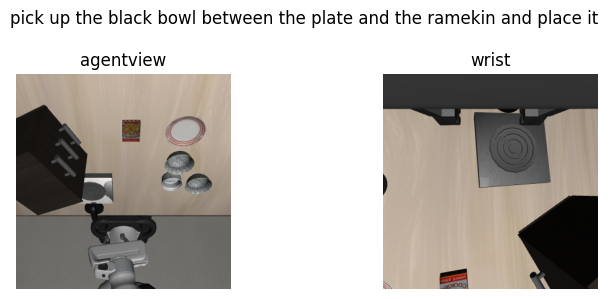

All checks passed!


In [ ]:
import time, os, torch, numpy as np
import mujoco, robosuite, lerobot
from libero.libero import benchmark, get_libero_path
from libero.libero.envs import OffScreenRenderEnv
from lerobot.policies.smolvla.modeling_smolvla import SmolVLAPolicy

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')
print(f'MuJoCo: {mujoco.__version__}')
print(f'MUJOCO_GL: {os.environ.get("MUJOCO_GL")}')

# Load policy
policy = SmolVLAPolicy.from_pretrained('HuggingFaceVLA/smolvla_libero').to(device).eval()
n_params = sum(p.numel() for p in policy.parameters()) / 1e6
vram = torch.cuda.memory_allocated()/1e9 if device=='cuda' else 0
print(f'SmolVLA: {n_params:.0f}M params, {vram:.2f} GB VRAM')

# Quick render test
bm = benchmark.get_benchmark_dict()
task_suite = bm['libero_spatial']()
task = task_suite.get_task(0)

bddl_file_path = os.path.join(
    get_libero_path("bddl_files"),
    task.problem_folder,
    task.bddl_file
)
print(f'BDDL path: {bddl_file_path}')

env = OffScreenRenderEnv(
    bddl_file_name=bddl_file_path,
    camera_names=['agentview', 'robot0_eye_in_hand'],
    camera_heights=360, camera_widths=360,   # fixed: was 128
    has_offscreen_renderer=True, use_camera_obs=True,
    has_renderer=False, reward_shaping=False,
)
obs = env.reset()

try:
    action_dim = env.action_dim
except AttributeError:
    try:
        action_dim = env.env.action_dim
    except AttributeError:
        try:
            action_dim = env.action_spec[0].shape[0]
        except Exception:
            action_dim = 7
print(f'Action dim: {action_dim}')

t0 = time.time()
for _ in range(5):
    action = np.random.uniform(-1, 1, size=(action_dim,))
    obs, *_ = env.step(action)
fps = 5 / (time.time() - t0)
env.close()
print(f'Rendering: {fps:.1f} fps')

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(8, 3))
axes[0].imshow(obs['agentview_image']); axes[0].set_title('agentview'); axes[0].axis('off')
axes[1].imshow(obs['robot0_eye_in_hand_image']); axes[1].set_title('wrist'); axes[1].axis('off')
plt.suptitle(task.language[:70]); plt.tight_layout(); plt.show()
print('All checks passed!')

In [5]:
# ── Configuration ─────────────────────────────
SUITE      = 'libero_spatial'  # libero_spatial | libero_object | libero_goal | libero_long
N_EPISODES = 10                 # per task. Use 1 for smoke test, 10 for proper eval
START_SEED = 0
MAX_STEPS  = 600
VERBOSE    = True
# ───────────────────────────────────────────────
print(f'{SUITE} | {N_EPISODES} ep/task | {N_EPISODES*10} total episodes')

libero_spatial | 10 ep/task | 100 total episodes


In [6]:
from transformers import AutoTokenizer
from lerobot.policies.pi05.modeling_pi05 import PI05Policy
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# ── Load model & tokenizer ──────────────────────────────────────────────
policy = PI05Policy.from_pretrained('lerobot/pi05_libero_finetuned')
policy = policy.to(device)
policy.eval()

tokenizer = AutoTokenizer.from_pretrained('google/paligemma-3b-pt-224')
print(f'PI05 loaded. Params: {sum(p.numel() for p in policy.parameters())/1e6:.0f}M')


The PI05 model is a direct port of the OpenPI implementation. 
This implementation follows the original OpenPI structure for compatibility. 
Original implementation: https://github.com/Physical-Intelligence/openpi


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading model from: lerobot/pi05_libero_finetuned
Could not load state dict from remote files: could not determine the shape of object type 'torch.storage.UntypedStorage'
Returning model without loading pretrained weights


KeyboardInterrupt: 

In [ ]:
import time, json, torch, numpy as np, os, math
from tqdm.notebook import tqdm
from libero.libero import benchmark, get_libero_path
from libero.libero.envs import OffScreenRenderEnv
from lerobot.policies.pi05.modeling_pi05 import PI05Policy

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

CAMERAS = ['agentview', 'robot0_eye_in_hand']
CAMERA_KEY_MAP = {
    'agentview':          'observation.images.image',
    'robot0_eye_in_hand': 'observation.images.image2',
}
IMG_SIZE = 360           # render resolution; policy resizes internally
LIBERO_DUMMY_ACTION = [0.0] * 6 + [-1.0]
NUM_STEPS_WAIT = 10

# pi0.5 expects an empty (zero) third camera
EMPTY_CAM_SHAPE = (1, 3, 224, 224)


def _quat2axisangle(quat):
    if quat[3] > 1.0:  quat[3] = 1.0
    elif quat[3] < -1.0: quat[3] = -1.0
    den = np.sqrt(1.0 - quat[3] * quat[3])
    if math.isclose(den, 0.0):
        return np.zeros(3)
    return (quat[:3] * 2.0 * math.acos(quat[3])) / den


from lerobot.policies.factory import make_pre_post_processors

# Create official pre/post processors after loading policy
preprocess, postprocess = make_pre_post_processors(
    policy.config,
    'lerobot/pi05_libero_finetuned',
    preprocessor_overrides={"device_processor": {"device": str(device)}},
)

def obs_to_policy(obs_dict, task_desc, device):
    agentview = np.ascontiguousarray(obs_dict['agentview_image'][::-1, ::-1])
    wrist     = np.ascontiguousarray(obs_dict['robot0_eye_in_hand_image'][::-1, ::-1])

    img_agent = torch.from_numpy(agentview / 255.0).permute(2,0,1).float()
    img_wrist = torch.from_numpy(wrist     / 255.0).permute(2,0,1).float()

    state = np.concatenate([
        obs_dict['robot0_eef_pos'],
        _quat2axisangle(obs_dict['robot0_eef_quat']),
        obs_dict['robot0_gripper_qpos'],
    ])

    # Pass raw observation — preprocessor handles normalization, tokenization etc.
    return {
        'observation.images.image':  img_agent,
        'observation.images.image2': img_wrist,
        'observation.state': torch.from_numpy(state).float(),
        'task': task_desc,
    }

def run_episode(env, init_state, policy, task_desc, max_steps, device):
    env.reset()
    policy.reset()
    obs = env.set_init_state(init_state)
    for _ in range(NUM_STEPS_WAIT):
        obs, _, _, _ = env.step(LIBERO_DUMMY_ACTION)

    t0 = time.time()
    for step in range(max_steps):
        raw_obs = obs_to_policy(obs, task_desc, device)
        batch = preprocess(raw_obs)        # official preprocessing
        with torch.no_grad():
            action = policy.select_action(batch)
        action = postprocess(action)       # official postprocessing
        if isinstance(action, torch.Tensor):
            action = action.squeeze(0).cpu().numpy()
        obs, _, done, _ = env.step(action)
        if env.check_success():
            return True, step+1, time.time()-t0
        if done:
            break
    return False, step+1, time.time()-t0


policy = PI05Policy.from_pretrained('lerobot/pi05_libero_finetuned').to(device).eval()
task_suite = benchmark.get_benchmark_dict()[SUITE]()
print(f'Ready. {task_suite.n_tasks} tasks on {device}')


The PI05 model is a direct port of the OpenPI implementation. 
This implementation follows the original OpenPI structure for compatibility. 
Original implementation: https://github.com/Physical-Intelligence/openpi
Loading model from: lerobot/pi05_libero_finetuned


✓ Loaded state dict from model.safetensors
All keys loaded successfully!
[info] using task orders [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Ready. 10 tasks on cuda


Purely a debugging cell used before for SmolVLA, feel free to ignore

In [ ]:
# import os

# task = task_suite.get_task(0)
# bddl_file_path = os.path.join(get_libero_path("bddl_files"), task.problem_folder, task.bddl_file)
# init_states = task_suite.get_task_init_states(0)

# debug_env = OffScreenRenderEnv(
#     bddl_file_name=bddl_file_path, camera_names=CAMERAS,
#     camera_heights=360, camera_widths=360,
#     has_offscreen_renderer=True, use_camera_obs=True,
#     has_renderer=False, reward_shaping=False,
# )

# try:
#     debug_env.reset()
#     policy.reset()
#     obs = debug_env.set_init_state(init_states[0])
#     for _ in range(NUM_STEPS_WAIT):
#         obs, _, _, _ = debug_env.step(LIBERO_DUMMY_ACTION)

#     # Print bowl position for reference
#     print('Bowl pos:', np.round(obs.get('akita_black_bowl_1_pos', np.array([0,0,0])), 3))
#     print('EEF start:', np.round(obs['robot0_eef_pos'], 3))
#     print()
#     print(f'{"Step":>5}  {"grip_act":>8}  {"grip_qpos":>20}  {"eef_xyz":>30}')

#     for step in range(60):
#         obs_in = obs_to_policy(obs, task.language, device)
#         with torch.no_grad():
#             action = policy.select_action(obs_in)
#         if isinstance(action, torch.Tensor):
#             action = action.squeeze(0).cpu().numpy()

#         eef = obs['robot0_eef_pos']
#         qpos = obs['robot0_gripper_qpos']
#         print(f'{step:>5}  {action[-1]:>8.3f}  {str(np.round(qpos,3)):>20}  {np.round(eef,3)}')

#         action[-1] = 1.0 - action[-1]
#         obs, _, done, _ = debug_env.step(action)
#         if debug_env.check_success():
#             print('SUCCESS')
#             break
# finally:
#     debug_env.close()

Bowl pos: [-0.063  0.202  0.898]
EEF start: [-0.211 -0.011  1.174]

 Step  grip_act             grip_qpos                         eef_xyz
    0    -0.926       [ 0.039 -0.039]  [-0.211 -0.011  1.174]
    1    -0.921       [ 0.039 -0.039]  [-0.21  -0.011  1.167]
    2    -0.932       [ 0.037 -0.037]  [-0.198 -0.007  1.163]
    3     1.033       [ 0.034 -0.033]  [-0.18   0.     1.165]
    4    -0.910       [ 0.031 -0.031]  [-0.166  0.005  1.165]
    5    -0.967         [ 0.03 -0.03]  [-0.154  0.003  1.16 ]
    6    -0.892       [ 0.028 -0.028]  [-0.14  -0.007  1.155]
    7    -0.963       [ 0.024 -0.024]  [-0.123 -0.019  1.155]
    8    -0.962         [ 0.02 -0.02]  [-0.117 -0.016  1.149]
    9    -0.936       [ 0.016 -0.015]  [-0.121 -0.017  1.143]
   10    -0.947       [ 0.011 -0.01 ]  [-0.115 -0.009  1.143]
   11    -0.948       [ 0.007 -0.007]  [-0.099 -0.003  1.142]
   12    -0.953       [ 0.005 -0.004]  [-0.087  0.012  1.139]
   13    -0.941       [ 0.004 -0.002]  [-0.081  0.039  1

Verify that policy can consistently succeed on various tasks in LIBERO Spatial

In [ ]:
all_results = []
suite_start = time.time()

# Task-specific max steps from reference script
MAX_STEPS_MAP = {
    'libero_spatial': 220,
    'libero_object':  280,
    'libero_goal':    300,
    'libero_10':      520,
    'libero_90':      400,
}
max_steps = MAX_STEPS_MAP.get(SUITE, 300)

for task_idx in range(task_suite.n_tasks):
    task = task_suite.get_task(task_idx)
    init_states = task_suite.get_task_init_states(task_idx)

    bddl_file_path = os.path.join(
        get_libero_path("bddl_files"), task.problem_folder, task.bddl_file)

    env = OffScreenRenderEnv(
        bddl_file_name=bddl_file_path, camera_names=CAMERAS,
        camera_heights=IMG_SIZE, camera_widths=IMG_SIZE,
        has_offscreen_renderer=True, use_camera_obs=True,
        has_renderer=False, reward_shaping=False,
    )

    print(f'\nTask {task_idx+1}/{task_suite.n_tasks}: {task.language[:65]}...')
    n_success = 0

    for ep_idx in tqdm(range(min(N_EPISODES, len(init_states))), desc=f'  T{task_idx+1}'):
        success, n_steps, elapsed = run_episode(
            env, init_states[ep_idx], policy, task.language, max_steps, device)
        n_success += int(success)
        all_results.append({
            'suite': SUITE, 'task_idx': task_idx,
            'task_description': task.language, 'episode': ep_idx,
            'success': success, 'n_steps': n_steps, 'elapsed_s': round(elapsed, 2)
        })
        if VERBOSE:
            print(f'    {"✓" if success else "✗"} ep{ep_idx} | {n_steps} steps | {elapsed:.1f}s')

    env.close()
    print(f'  SR: {n_success/N_EPISODES:.0%} ({n_success}/{N_EPISODES})')

    ts = time.strftime('%Y%m%d_%H%M%S')
    with open(f'{RESULTS_DIR}/partial_{SUITE}_{ts}.json', 'w') as f:
        json.dump(all_results, f)

overall_sr = sum(r['success'] for r in all_results) / len(all_results)
total_min = (time.time() - suite_start) / 60
print(f'\nOverall SR: {overall_sr:.1%} | Time: {total_min:.1f} min')


Task 1/10: pick up the black bowl between the plate and the ramekin and plac...


  T1:   0%|          | 0/10 [00:00<?, ?it/s]

    ✓ ep0 | 77 steps | 23.1s
    ✓ ep1 | 74 steps | 22.0s
    ✓ ep2 | 76 steps | 22.6s
    ✓ ep3 | 80 steps | 24.0s
    ✓ ep4 | 79 steps | 23.5s
    ✓ ep5 | 80 steps | 24.2s
    ✓ ep6 | 71 steps | 21.3s
    ✓ ep7 | 82 steps | 24.4s
    ✓ ep8 | 79 steps | 23.6s
    ✓ ep9 | 71 steps | 21.2s
  SR: 100% (10/10)

Task 2/10: pick up the black bowl next to the ramekin and place it on the pl...


  T2:   0%|          | 0/10 [00:00<?, ?it/s]

    ✓ ep0 | 108 steps | 31.7s
    ✓ ep1 | 112 steps | 33.7s
    ✓ ep2 | 111 steps | 33.0s
    ✓ ep3 | 110 steps | 32.0s
    ✓ ep4 | 121 steps | 35.4s
    ✓ ep5 | 117 steps | 34.6s
    ✓ ep6 | 113 steps | 33.8s
    ✗ ep7 | 220 steps | 63.1s
    ✓ ep8 | 107 steps | 31.7s
    ✓ ep9 | 108 steps | 32.1s
  SR: 90% (9/10)

Task 3/10: pick up the black bowl from table center and place it on the plat...


...

    ✓ ep0 | 85 steps | 25.3s
    ✓ ep1 | 88 steps | 26.4s
    ✓ ep2 | 79 steps | 23.9s
    ✓ ep3 | 86 steps | 25.8s
    ✓ ep4 | 99 steps | 29.7s
    ✓ ep5 | 80 steps | 23.6s
    ✓ ep6 | 86 steps | 25.9s
    ✓ ep7 | 81 steps | 24.5s
    ✓ ep8 | 87 steps | 25.7s
    ✓ ep9 | 83 steps | 25.1s
  SR: 100% (10/10)

Task 5/10: pick up the black bowl in the top drawer of the wooden cabinet an...


  T5:   0%|          | 0/10 [00:00<?, ?it/s]

    ✗ ep0 | 220 steps | 64.8s
    ✗ ep1 | 220 steps | 64.3s
    ✗ ep2 | 220 steps | 64.2s
    ✓ ep3 | 144 steps | 43.3s
    ✓ ep4 | 136 steps | 41.2s
    ✓ ep5 | 132 steps | 40.4s
    ✓ ep6 | 128 steps | 38.2s
    ✓ ep7 | 132 steps | 39.9s
    ✓ ep8 | 136 steps | 41.1s
    ✓ ep9 | 129 steps | 39.4s
  SR: 70% (7/10)

Task 6/10: pick up the black bowl on the ramekin and place it on the plate...


  T6:   0%|          | 0/10 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
import imageio
from IPython.display import Video, display

task = task_suite.get_task(0)
bddl_file_path = os.path.join(get_libero_path("bddl_files"), task.problem_folder, task.bddl_file)
init_states = task_suite.get_task_init_states(0)

video_env = OffScreenRenderEnv(
    bddl_file_name=bddl_file_path, camera_names=CAMERAS,
    camera_heights=IMG_SIZE, camera_widths=IMG_SIZE,
    has_offscreen_renderer=True, use_camera_obs=True,
    has_renderer=False, reward_shaping=False,
)

try:
    video_env.reset()
    policy.reset()
    obs = video_env.set_init_state(init_states[0])
    for _ in range(NUM_STEPS_WAIT):
        obs, _, _, _ = video_env.step(LIBERO_DUMMY_ACTION)

    frames = []
    print(f"Recording: '{task.language}'...")

    for step in range(220):
        frames.append(np.ascontiguousarray(obs['agentview_image'][::-1, ::-1]))

        raw_obs = obs_to_policy(obs, task.language, device)
        batch = preprocess(raw_obs)              # official preprocessing
        with torch.no_grad():
            action = policy.select_action(batch)
        action = postprocess(action)             # official postprocessing
        if isinstance(action, torch.Tensor):
            action = action.squeeze(0).cpu().numpy()

        obs, _, done, _ = video_env.step(action)
        if video_env.check_success():
            print("Task succeeded!")
            break

    video_path = '/content/rollout.mp4'
    imageio.mimsave(video_path, frames, fps=30)
    display(Video(video_path, embed=True, width=512))
finally:
    video_env.close()

Recording: 'pick up the black bowl between the plate and the ramekin and place it on the plate'...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Task succeeded!


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


---
## Section 5: Benchmark Reproduction

In [ ]:
# ── Configuration ─────────────────────────────────────────────────────
SUITES     = ['libero_spatial', 'libero_object', 'libero_goal', 'libero_10']
N_EPISODES = 10
VERBOSE    = True

MAX_STEPS_MAP = {
    'libero_spatial': 220,
    'libero_object':  280,
    'libero_goal':    300,
    'libero_10':      520,
    'libero_90':      400,
}
print(f'Will evaluate: {SUITES}')
print(f'{N_EPISODES} episodes/task | {N_EPISODES * 10 * len(SUITES)} total episodes')

Will evaluate: ['libero_spatial', 'libero_object', 'libero_goal', 'libero_10']
10 episodes/task | 400 total episodes


Apparently in LIBERO it's standard to run each task for 50 episodes (this is what Claude told me) but I'm just running 10 episodes for the signal

In [ ]:
import json, time
from tqdm.notebook import tqdm

all_results = []
benchmark_dict = benchmark.get_benchmark_dict()
total_start = time.time()

for SUITE in tqdm(SUITES, desc='Suites'):
    print(f'\n{"="*60}')
    print(f'Suite: {SUITE}')
    print(f'{"="*60}')

    task_suite = benchmark_dict[SUITE]()
    max_steps = MAX_STEPS_MAP.get(SUITE, 300)
    suite_start = time.time()
    suite_results = []

    for task_idx in tqdm(range(task_suite.n_tasks), desc=f'  {SUITE} tasks', leave=False):
        task = task_suite.get_task(task_idx)
        init_states = task_suite.get_task_init_states(task_idx)

        bddl_file_path = os.path.join(
            get_libero_path("bddl_files"), task.problem_folder, task.bddl_file)

        env = OffScreenRenderEnv(
            bddl_file_name=bddl_file_path, camera_names=CAMERAS,
            camera_heights=IMG_SIZE, camera_widths=IMG_SIZE,
            has_offscreen_renderer=True, use_camera_obs=True,
            has_renderer=False, reward_shaping=False,
        )

        n_success = 0
        ep_bar = tqdm(range(min(N_EPISODES, len(init_states))),
                      desc=f'    T{task_idx+1} ({task.language[:40]}...)',
                      leave=False)

        for ep_idx in ep_bar:
            success, n_steps, elapsed = run_episode(
                env, init_states[ep_idx], policy, task.language, max_steps, device)
            n_success += int(success)
            result = {
                'suite': SUITE, 'task_idx': task_idx,
                'task_description': task.language,
                'episode': ep_idx, 'success': success,
                'n_steps': n_steps, 'elapsed_s': round(elapsed, 2)
            }
            suite_results.append(result)
            all_results.append(result)
            ep_bar.set_postfix(sr=f'{n_success}/{ep_idx+1}',
                               status='✓' if success else '✗')

        tqdm.write(f'  T{task_idx+1} SR: {n_success/N_EPISODES:.0%} ({n_success}/{N_EPISODES}) — {task.language[:50]}...')
        env.close()

    suite_sr = sum(r['success'] for r in suite_results) / len(suite_results)
    suite_min = (time.time() - suite_start) / 60
    tqdm.write(f'\n{SUITE} SR: {suite_sr:.1%} | Time: {suite_min:.1f} min')

    ts = time.strftime('%Y%m%d_%H%M%S')
    with open(f'{RESULTS_DIR}/partial_pi05_{SUITE}_{ts}.json', 'w') as f:
        json.dump(suite_results, f)

overall_sr = sum(r['success'] for r in all_results) / len(all_results)
total_min = (time.time() - total_start) / 60
print(f'\n{"="*60}')
print(f'OVERALL SR: {overall_sr:.1%} ({sum(r["success"] for r in all_results)}/{len(all_results)})')
print(f'Total time: {total_min:.1f} min')
print(f'{"="*60}')

Suites:   0%|          | 0/4 [00:00<?, ?it/s]


Suite: libero_spatial
[info] using task orders [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


  libero_spatial tasks:   0%|          | 0/10 [00:00<?, ?it/s]

    T1 (pick up the black bowl between the plate...):   0%|          | 0/10 [00:00<?, ?it/s]

  T1 SR: 100% (10/10) — pick up the black bowl between the plate and the r...


...

  T8 SR: 90% (9/10) — put both the alphabet soup and the cream cheese bo...


    T9 (put both moka pots on the stove...):   0%|          | 0/10 [00:00<?, ?it/s]

  T9 SR: 80% (8/10) — put both moka pots on the stove...


    T10 (put the yellow and white mug in the micr...):   0%|          | 0/10 [00:00<?, ?it/s]

  T10 SR: 90% (9/10) — put the yellow and white mug in the microwave and ...

libero_10 SR: 90.0% | Time: 106.9 min

OVERALL SR: 92.5% (370/400)
Total time: 297.0 min


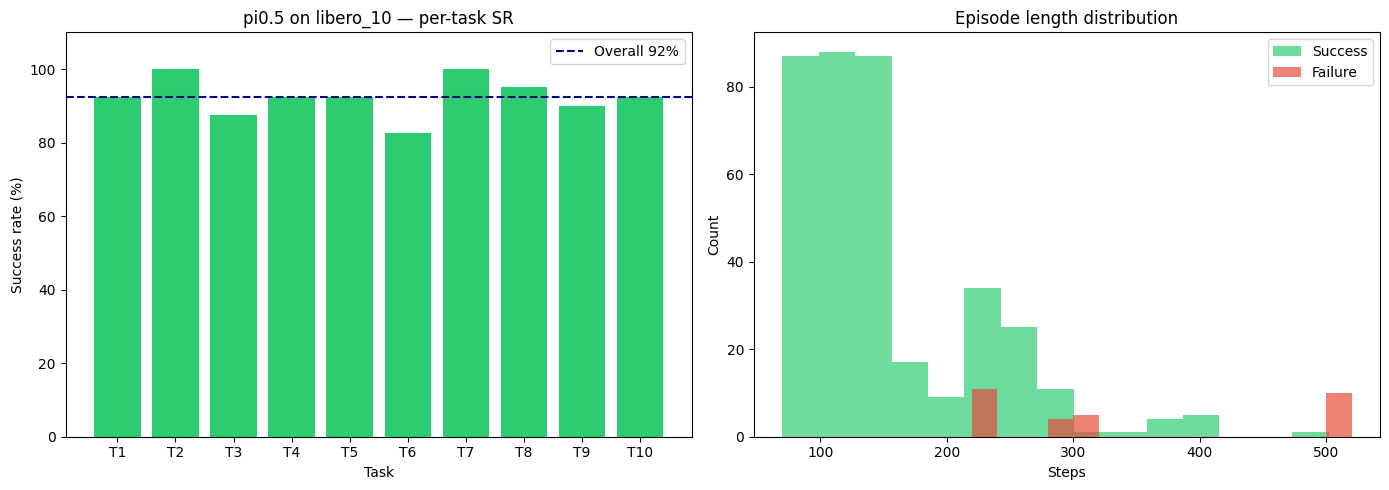

Results saved to Drive: /content/drive/MyDrive/smolvla_results/pi05_libero_10_10ep_20260516_215522.json


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Per-task breakdown
task_srs = []
task_labels = []
for i in range(task_suite.n_tasks):
    eps = [r for r in all_results if r['task_idx'] == i]
    sr = sum(r['success'] for r in eps) / len(eps)
    task_srs.append(sr)
    task_labels.append(f'T{i+1}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Success rate per task
colors = ['#2ecc71' if s >= 0.5 else '#e74c3c' for s in task_srs]
axes[0].bar(task_labels, [s * 100 for s in task_srs], color=colors)
axes[0].axhline(overall_sr * 100, color='navy', linestyle='--',
                label=f'Overall {overall_sr:.0%}')
axes[0].set(xlabel='Task', ylabel='Success rate (%)',
            title=f'pi0.5 on {SUITE} — per-task SR', ylim=(0, 110))
axes[0].legend()

# Episode length distribution
s_steps = [r['n_steps'] for r in all_results if r['success']]
f_steps = [r['n_steps'] for r in all_results if not r['success']]
if s_steps: axes[1].hist(s_steps, bins=15, alpha=0.7, color='#2ecc71', label='Success')
if f_steps: axes[1].hist(f_steps, bins=15, alpha=0.7, color='#e74c3c', label='Failure')
axes[1].set(xlabel='Steps', ylabel='Count', title='Episode length distribution')
axes[1].legend()

plt.tight_layout()
ts = time.strftime('%Y%m%d_%H%M%S')
plt.savefig(f'{RESULTS_DIR}/pi05_{SUITE}_{ts}.png', dpi=150)
plt.show()

# Save final results
out_file = f'{RESULTS_DIR}/pi05_{SUITE}_{N_EPISODES}ep_{ts}.json'
with open(out_file, 'w') as f:
    json.dump({
        'config': {
            'model': 'lerobot/pi05_libero_finetuned',
            'suite': SUITE,
            'n_episodes': N_EPISODES,
            'max_steps': max_steps,
        },
        'summary': {
            'overall_sr': overall_sr,
            'per_task_sr': {f'task_{i}': task_srs[i] for i in range(len(task_srs))},
            'total_episodes': len(all_results),
            'elapsed_min': total_min,
        },
        'episodes': all_results,
    }, f, indent=2)
print(f'Results saved to Drive: {out_file}')

# because i'm going to sleep while this is running lol
from google.colab import runtime
runtime.unassign()